## ❓ What does covariance measure?

Covariance measures **how two variables change together**.

- Positive covariance → variables move in the **same direction**
- Negative covariance → variables move in **opposite directions**
- Near zero → little or no linear relationship

👉 Covariance mainly indicates **direction**, not standardized strength.

---

## ❓ Can covariance indicate strength of relationship clearly? Why or why not?

**No — covariance cannot clearly indicate strength.**

### Reason:

- Covariance depends on the **units** of measurement
- Larger scales produce larger covariance values
- It has **no fixed range** for comparison

👉 Therefore, covariance shows direction but not interpretable strength.

---

## ❓ What does Pearson correlation measure?

Pearson correlation measures the **strength and direction of a linear relationship** between two variables.

### Range:

```
-1  → Perfect negative relationship
 0  → No linear relationship
+1  → Perfect positive relationship
```

👉 It is standardized, making interpretation easier.

---

## ❓ When should Pearson correlation not be used?

Pearson correlation is not appropriate when:

- Relationship is **non-linear**
- Data contains **strong outliers**
- Variables are **ordinal**
- Data violates **normality assumptions**

👉 Pearson assumes linear, numeric relationships.

---

## ❓ What is Spearman rank correlation?

Spearman rank correlation measures the **strength and direction of a monotonic relationship** using ranked values.

### Key features:

- Works with ranked or ordinal data
- Less sensitive to outliers
- Detects monotonic trends

👉 Suitable when raw values are unreliable.

---

## ❓ When should Spearman be preferred over Pearson?

Use Spearman correlation when:

- Relationship is **monotonic but not linear**
- Data has **outliers**
- Variables are **ordinal/ranked**
- Normal distribution assumption fails

👉 Spearman is more robust in non-ideal conditions.

---

## 📌 Conclusion

- Covariance → Direction only  
- Pearson → Linear relationship strength  
- Spearman → Ranked/monotonic relationship  

Understanding when to use each method ensures accurate statistical analysis.

---


# Question 1: Advertising vs Sales (Pearson Correlation)

### A company wants to examine whether Advertising Budget affects Sales.

**Advertising (₹ Lakhs):** [8, 10, 12, 15, 18, 20, 22, 25]

**Sales (₹ Lakhs):** [38, 40, 43, 48, 52, 55, 58, 62]

**📝 Tasks**
1. Compute covariance.
2. Compute Pearson correlation coefficient.
3. State hypotheses:
    H₀: r = 0
    H₁: r ≠ 0
4. Plot scatter diagram and explain pattern.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import pearsonr

advertising = np.array([8, 10, 12, 15, 18, 20, 22, 25])
sales = np.array([38, 40, 43, 48, 52, 55, 58, 62])

n = len(advertising)
# Step 1 — Means
mean_x = sum(advertising) / n
mean_y = sum(sales) / n

# Step 2 — Covariance (manual)\
cov_sum = 0
for i in range(n):
    cov_sum += (advertising[i] - mean_x) * (sales[i] - mean_y)

covariance = cov_sum / (n - 1)

# Step 3 — Standard Deviations
sx_sum = 0
sy_sum = 0

for i in range(n):
    sx_sum += (advertising[i] - mean_x) ** 2
    sy_sum += (sales[i] - mean_y) ** 2

std_x = math.sqrt(sx_sum / (n - 1))
std_y = math.sqrt(sy_sum / (n - 1))

# Step 4 — Pearson Correlation
# -----------------------------
r = covariance / (std_x * std_y)

# Step 5 — Output Results
# -----------------------------
print("Mean Advertising:", mean_x)
print("Mean Sales:", mean_y)

print("\nCovariance:", covariance)
print("Pearson Correlation (r):", r)

Mean Advertising: 16.25
Mean Sales: 49.5

Covariance: 52.42857142857143
Pearson Correlation (r): 0.9993583977829131


Covariance: 52.42857142857142
Pearson correlation coefficient (r): 0.9993583977829131
p-value: 6.599766492871318e-10

Hypotheses:
H0: r = 0 (No relationship)
H1: r ≠ 0 (Significant relationship)
Decision: Reject H0


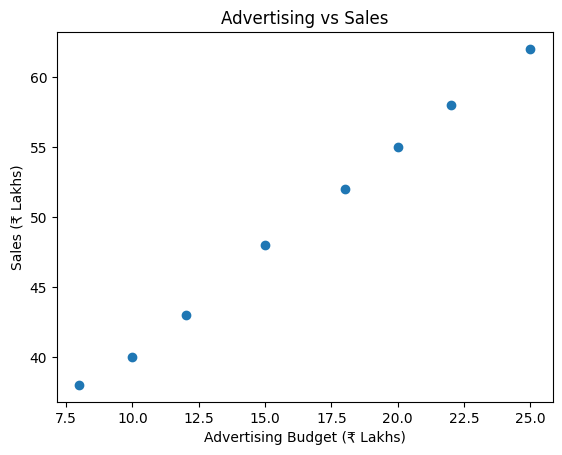


Interpretation:
The scatter plot shows an upward trend,
indicating a strong positive linear relationship.
Higher advertising budgets are associated with higher sales.


In [2]:
# Step 1 — Covariance
cov_matrix = np.cov(advertising, sales)
covariance = cov_matrix[0, 1]

print("Covariance:", covariance)

# Step 2 — Pearson Correlation
r, p_value = pearsonr(advertising, sales)

print("Pearson correlation coefficient (r):", r)
print("p-value:", p_value)

# Step 3 — Hypothesis Testing
alpha = 0.05

print("\nHypotheses:")
print("H0: r = 0 (No relationship)")
print("H1: r ≠ 0 (Significant relationship)")

if p_value < alpha:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")

# Step 4 — Scatter Plot
plt.figure()
plt.scatter(advertising, sales)

plt.title("Advertising vs Sales")
plt.xlabel("Advertising Budget (₹ Lakhs)")
plt.ylabel("Sales (₹ Lakhs)")

plt.show()

# Interpretation
print("\nInterpretation:")
print("The scatter plot shows an upward trend,")
print("indicating a strong positive linear relationship.")
print("Higher advertising budgets are associated with higher sales.")


# Question 2: 
## Training Hours vs Productivity Rank (Spearman)

### An HR department studies whether Training Hours rank relates to Productivity rank.

**Training Rank:** [1, 2, 3, 4, 5, 6, 7, 8]

**Productivity Rank:** [2, 1, 4, 3, 6, 5, 8, 7]

**📝 Tasks**

1. Compute Spearman correlation.
2. State hypotheses: \
    H₀: ρ = 0 \
    H₁: ρ ≠ 0
4. Interpret results in HR decision-making context.

In [12]:
training = [1,2,3,4,5,6,7,8]
productivity = [2,1,4,3,6,5,8,7]
n = len(training)

# Step 1 — Compute d and d²
d_squared_sum = 0 
print("Rank Difference Table : ")
print("train Prod d d²")

for i in range(n):
    d = training[i] - productivity[i]
    d2 = d**2
    d_squared_sum += d2
    print(training[i], productivity[i], d, d2)

# Step 2 — Spearman Formula
# ρ = 1 - (6 Σd² / n(n²-1))
rho = 1 - (6 * d_squared_sum) / (n * (n**2 - 1))

print("\nΣd² =", d_squared_sum)
print("Spearman Correlation (ρ):", rho)

print("\nHypothesis:")
print("H0: ρ = 0")
print("H1: ρ ≠ 0")

if abs(rho) > 0.5:
    print("Decision: Reject H0 (meaningful relationship)")
else:
    print("Decision: Fail to reject H0")

Rank Difference Table : 
train Prod d d²
1 2 -1 1
2 1 1 1
3 4 -1 1
4 3 1 1
5 6 -1 1
6 5 1 1
7 8 -1 1
8 7 1 1

Σd² = 8
Spearman Correlation (ρ): 0.9047619047619048

Hypothesis:
H0: ρ = 0
H1: ρ ≠ 0
Decision: Reject H0 (meaningful relationship)


In [11]:
# 📊 Spearman Rank Correlation (Library Method)

from scipy.stats import spearmanr

training = [1, 2, 3, 4, 5, 6, 7, 8]
productivity = [2, 1, 4, 3, 6, 5, 8, 7]

rho, p_value = spearmanr(training, productivity)

print("Spearman Correlation (ρ):", rho)
print("p-value:", p_value)

# Hypothesis Testing
alpha = 0.05

print("\nHypothesis:")
print("H0: ρ = 0")
print("H1: ρ ≠ 0")

if p_value < alpha:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")


Spearman Correlation (ρ): 0.9047619047619048
p-value: 0.0020082755054294677

Hypothesis:
H0: ρ = 0
H1: ρ ≠ 0
Decision: Reject H0


# Question 3: Pearson vs Spearman Comparison

### Using the dataset from Part 1:

- Add an extreme outlier to Sales.
- Recalculate Pearson correlation.
- Recalculate Spearman correlation.
- Compare results.
- Which method is more robust?
- Explain practical implications.

In [13]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

advertising = np.array([8, 10, 12, 15, 18, 20, 22, 25])
sales = np.array([38, 40, 43, 48, 52, 55, 58, 62])

# Add extreme outlier
advertising = np.append(advertising, 30)
sales = np.append(sales, 200)

print("Dataset with outlier:")
print("Advertising:", advertising)
print("Sales:", sales)

# Pearson Correlation
pearson_r, pearson_p = pearsonr(advertising, sales)

# Spearman Correlation
spearman_rho, spearman_p = spearmanr(advertising, sales)

# Results
print("\nPearson Correlation (r):", pearson_r)
print("Pearson p-value:", pearson_p)

print("\nSpearman Correlation (ρ):", spearman_rho)
print("Spearman p-value:", spearman_p)

# Comparison Interpretation
print("\nComparison:")
print("Pearson correlation is strongly affected by the outlier.")
print("Spearman correlation remains more stable.")

print("\nConclusion:")
print("Spearman method is more robust to extreme values.")

print("\nPractical Implication:")
print("Use Spearman when data contains outliers or ranking behavior.")


Dataset with outlier:
Advertising: [ 8 10 12 15 18 20 22 25 30]
Sales: [ 38  40  43  48  52  55  58  62 200]

Pearson Correlation (r): 0.7475530984245056
Pearson p-value: 0.020579855377297316

Spearman Correlation (ρ): 1.0
Spearman p-value: 0.0

Comparison:
Pearson correlation is strongly affected by the outlier.
Spearman correlation remains more stable.

Conclusion:
Spearman method is more robust to extreme values.

Practical Implication:
Use Spearman when data contains outliers or ranking behavior.
